# Model Training V3
Competitive matches only | 39 features | Recency weighted

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

BASE = r'C:\Project\FIFA_World_Cup_2026'

features_df = pd.read_csv(os.path.join(BASE, 'Feature_Engineering', 'features_v3.csv'))

print("Shape:", features_df.shape)
print("Columns:", len(features_df.columns))

Shape: (5831, 39)
Columns: 39


## Prepare Training Data

In [2]:
feature_cols = [
    'home_form', 'away_form', 'form_diff',
    'home_avg_scored', 'home_avg_conceded',
    'away_avg_scored', 'away_avg_conceded',
    'goal_diff', 'is_neutral',
    'home_elo', 'away_elo', 'elo_diff',
    'home_elo_winrate', 'away_elo_winrate',
    'home_star_elo', 'away_star_elo', 'star_elo_diff',
    'home_attack', 'away_attack', 'attack_diff',
    'home_defense', 'away_defense', 'defense_diff',
    'home_mid', 'away_mid',
    'h2h', 'momentum_diff',
    'home_age_score', 'away_age_score',
    'home_conf_strength', 'away_conf_strength', 'conf_diff'
]

X = features_df[feature_cols]
y = features_df['result']
weights = features_df['weight']

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Features:", len(feature_cols))

Training set: (4664, 32)
Testing set: (1167, 32)
Features: 32


## Train Logistic Regression V3

In [3]:
lr_model = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train_enc, sample_weight=w_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test_enc, lr_preds)

print(f"Logistic Regression V3 Accuracy: {lr_accuracy:.4f}")

Logistic Regression V3 Accuracy: 0.5407


## Train XGBoost V3

In [4]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_enc, sample_weight=w_train)

xgb_preds = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test_enc, xgb_preds)

print(f"XGBoost V3 Accuracy: {xgb_accuracy:.4f}")

XGBoost V3 Accuracy: 0.5596


## Full Version Comparison

In [5]:
print("=" * 45)
print("       FULL VERSION COMPARISON")
print("=" * 45)
print(f"V1 Logistic Regression : 0.5211")
print(f"V1 XGBoost             : 0.5093")
print(f"V2 Logistic Regression : 0.5124")
print(f"V2 XGBoost             : 0.5483")
print(f"V3 Logistic Regression : {lr_accuracy:.4f}")
print(f"V3 XGBoost             : {xgb_accuracy:.4f}")
print("=" * 45)
print(f"Best model improvement : {(xgb_accuracy - 0.5093):.4f}")

       FULL VERSION COMPARISON
V1 Logistic Regression : 0.5211
V1 XGBoost             : 0.5093
V2 Logistic Regression : 0.5124
V2 XGBoost             : 0.5483
V3 Logistic Regression : 0.5407
V3 XGBoost             : 0.5596
Best model improvement : 0.0503


## Classification Report V3

In [6]:
print("XGBoost V3 Classification Report:")
print("=" * 45)
print(classification_report(y_test_enc, xgb_preds,
      target_names=['Away Win', 'Draw', 'Home Win']))

XGBoost V3 Classification Report:
              precision    recall  f1-score   support

    Away Win       0.53      0.57      0.55       364
        Draw       0.25      0.12      0.16       241
    Home Win       0.63      0.74      0.68       562

    accuracy                           0.56      1167
   macro avg       0.47      0.48      0.46      1167
weighted avg       0.52      0.56      0.53      1167



## Feature Importance V3

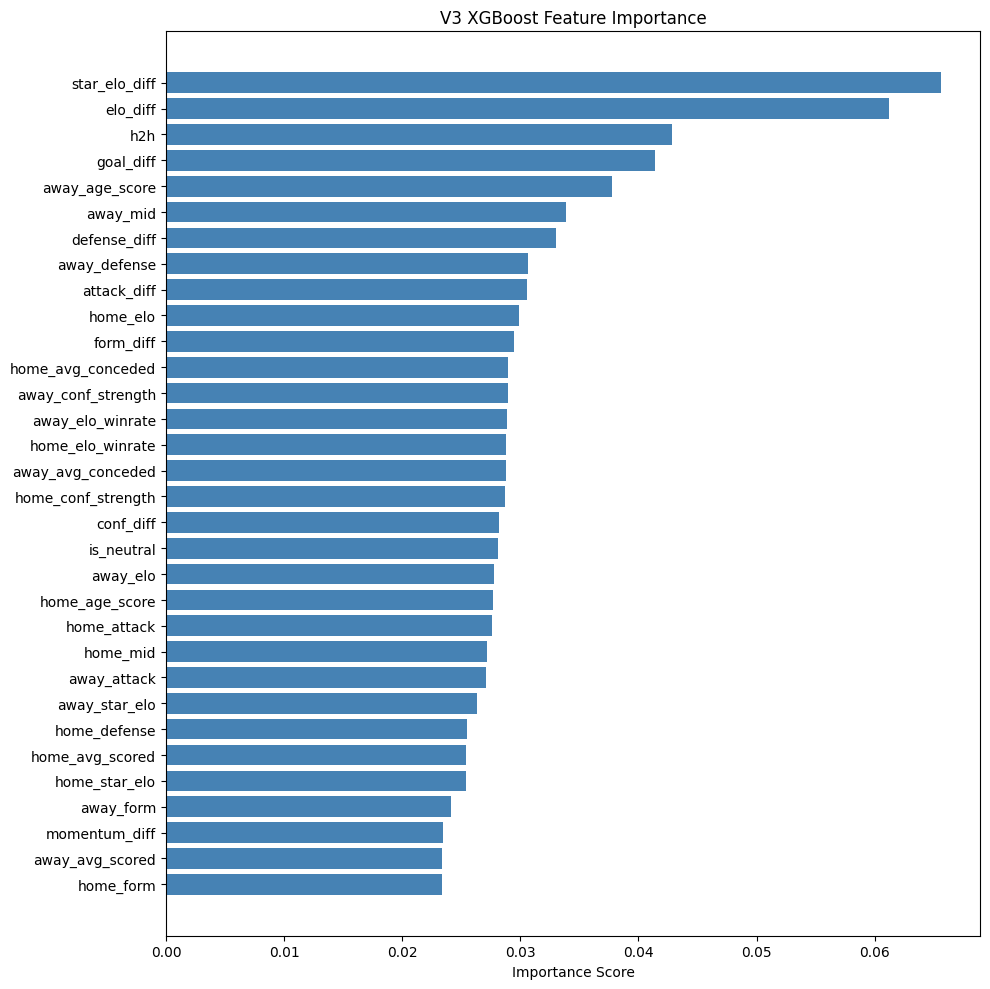


Top 5 features:
       feature  importance
away_age_score    0.037764
     goal_diff    0.041447
           h2h    0.042836
      elo_diff    0.061205
 star_elo_diff    0.065641


In [7]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('V3 XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'Evaluate', 'feature_importance_v3.png'))
plt.show()

print("\nTop 5 features:")
print(importance.tail(5)[['feature', 'importance']].to_string(index=False))

## Save V3 Models

In [8]:
with open(os.path.join(BASE, 'Model_Training', 'xgb_model_v3.pkl'), 'wb') as f:
    pickle.dump(xgb_model, f)

with open(os.path.join(BASE, 'Model_Training', 'lr_model_v3.pkl'), 'wb') as f:
    pickle.dump(lr_model, f)

with open(os.path.join(BASE, 'Model_Training', 'scaler_v3.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(BASE, 'Model_Training', 'label_encoder_v3.pkl'), 'wb') as f:
    pickle.dump(le, f)

print("V3 models saved!")

V3 models saved!
